# Plotting IQ Results with Plotnine — Part 1: Basics

[Plotnine](https://plotnine.org) is a Python library that implements the *grammar of graphics*, a principled way to describe and assemble plots. It is closely modelled on R's **ggplot2**, so the concepts transfer directly if you ever encounter ggplot2 code.

This notebook covers the core building blocks:

- Constructing a plot from **data**, **aesthetics**, and **geometries**
- Controlling axis scales and labels
- Coloring and distinguishing curves by a data variable
- Splitting a figure into panels (**facets**)
- Themes and saving finished figures

**Part 2** of this series builds on these basics with ready-to-use examples for optimization and sensitivity analysis results.

> **Prerequisites:** You should be comfortable running `abm.simulate()` and calling `.to_pandas()` on the result.

## Section 0 — Setup

In [1]:
import abm
import numpy as np
import pandas as pd
from plotnine import *

`from plotnine import *` brings every plotnine name — `ggplot`, `geom_line`, `aes`, `labs`, `theme`, and so on — directly into scope so you can use them without a `plotnine.` prefix. This is the standard pattern for interactive notebooks.

In [2]:
model = 'inputs/Models/2compartment_Ab.iqd'

Load the nominal parameter table.

In [3]:
Tpar = pd.read_csv('inputs/Parameters/Parameter.csv')

Build a dosing table: four dose levels, five weekly doses via IV and SC.

In [4]:
doses      = [1, 3, 10, 30]
dose_times = [0, 7, 14, 21, 28]

TdosIV = (pd.DataFrame({'dose_mpk': doses, 'amounts': doses,
                         'times': [dose_times] * len(doses)})
            .assign(time_unit='d', amount_unit='mg/kg', route='Dose_IV'))

TdosSC = (pd.DataFrame({'dose_mpk': doses, 'amounts': doses,
                         'times': [dose_times] * len(doses)})
            .assign(time_unit='d', amount_unit='mg/kg', route='Dose_SC'))

Tdos = pd.concat([TdosIV, TdosSC])
Tsim = Tdos[['dose_mpk', 'route']]

The model needs zero-valued initial dose parameters when custom dosing is supplied.

In [5]:
Tpar_ext = pd.concat([
    Tpar,
    pd.DataFrame({'parameter': ['Dose_amt_IV', 'Dose_amt_SC']})
      .assign(unit='mg/kg', value=0, is_fit=False)
])

Simulate the model.

In [6]:
Tsim_results = abm.simulate(
    models      = model,
    parameters  = Tpar_ext,
    doses       = Tdos,
    simulations = Tsim,
    outputs     = ['free_drug_c', 'RO_c'],
    times       = abm.linspace(0, 35, 351, 'd')
).to_pandas(tall_outputs=True)

display(Tsim_results.head(10))

Total: 0, Running: 0, Succeeded: 0, Failed: 0

,dose_mpk,route,id,t,output,value,output_unit
0,1,Dose_IV,0,0.0,free_drug_c,155.555556,nM
1,1,Dose_IV,0,0.0,RO_c,0.000000,1
2,1,Dose_IV,0,0.1,free_drug_c,130.957387,nM
3,1,Dose_IV,0,0.1,RO_c,59.268894,1
4,1,Dose_IV,0,0.2,free_drug_c,115.964521,nM
5,1,Dose_IV,0,0.2,RO_c,56.303897,1
6,1,Dose_IV,0,0.3,free_drug_c,103.715222,nM
7,1,Dose_IV,0,0.3,RO_c,53.540747,1
8,1,Dose_IV,0,0.4,free_drug_c,93.697792,nM
9,1,Dose_IV,0,0.4,RO_c,51.007125,1


The `tall_outputs=True` argument reshapes the result to *long format*: instead of one column per output, there is one row per time point per output, with an `output` column identifying which quantity was recorded and a `value` column holding the number. This layout is what plotnine expects. It maps a single `y` column to the y-axis.

Key columns used throughout this notebook:

| Column | Description |
|--------|-------------|
| `t` | Simulation time (days) |
| `output` | Output name (`'free_drug_c'` or `'RO_c'`) |
| `value` | Numeric result |
| `dose_mpk` | Dose in mg/kg |
| `route` | Dosing route (`'Dose_IV'` or `'Dose_SC'`) |

## Section 1 — The Grammar of Graphics

Most Python plotting tools work by calling functions for specific chart types, like `plt.plot()`, `plt.bar()`, and so on. Plotnine instead works by *describing* a plot: you declare its components, and the library assembles them.

The payoff is consistency. The same grammar handles almost any chart type, and it is easy to extend a finished plot (add a layer, change a scale, split into panels) without rewriting it from scratch.

### The three required components

Every plotnine plot needs three things:

1. **Data** — a pandas DataFrame
2. **Aesthetic mapping** (`aes`) — which DataFrame columns map to visual properties such as x-position, y-position, and color
3. **Geometry** (`geom_*`) — the visual mark drawn for each row of data (a line, a point, a bar, ...)

These are combined with `+`:

```python
ggplot(data, aes(x='col_a', y='col_b')) + geom_line()
```

Providing data in the `ggplot()` call uses the same data for every geometry added to the plot. Alternatively, data and mapping can be attached to individual geometry layers. This is especially useful when overlaying two different DataFrames (for example, observed data on top of model predictions):

```python
ggplot()
+ geom_line(data=predictions, mapping=aes(x='t',    y='value'))
+ geom_point(data=observed,   mapping=aes(x='time', y='measurement'))
```

Both patterns are valid. This tutorial uses the per-layer form, which is standard in IQ notebooks.

### Building up a plot by adding layers

Once you have a base `ggplot()` call, you extend it by adding components with `+`. Each `+` returns a new plot object, so you can store intermediate states or break a long expression across lines:

```python
fig = (ggplot()
       + geom_line(data=df, mapping=aes(x='t', y='value'))  # geometry
       + labs(x='Time (days)', y='Concentration (nM)')       # axis labels
       + scale_y_log10()                                      # log scale
      )
display(fig)
```

Wrapping the whole expression in parentheses `()` lets you split it across lines without needing backslashes. This is the standard formatting you will see in IQ notebooks.

## Section 2 — Plotting a Single Simulation Output

### Filtering to one output with `.query()`

Because `tall_outputs=True` stacks all outputs into a single `value` column, you usually need to filter to one output before plotting. The `.query()` method lets you write the filter as a readable expression:

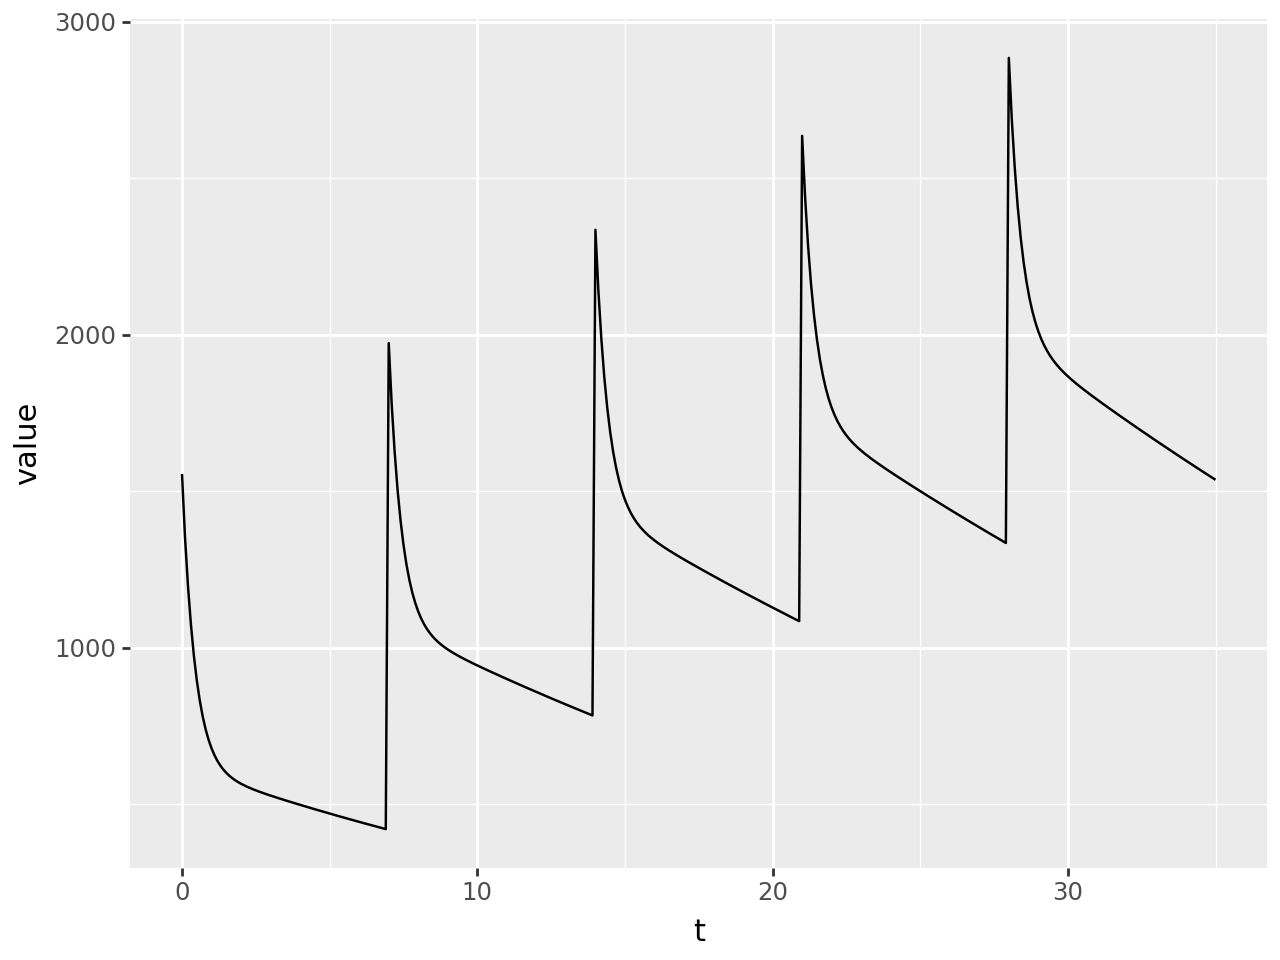

In [7]:
# Filter to the PK output for a single dose and route so the first example is simple
Tpk_single = Tsim_results.query('output == "free_drug_c" and dose_mpk == 10 and route == "Dose_IV"')

fig = (ggplot()
       + geom_line(data=Tpk_single, mapping=aes(x='t', y='value'))
      )
display(fig)

The default axis labels come from the column names. Use `labs()` to replace them with something informative:

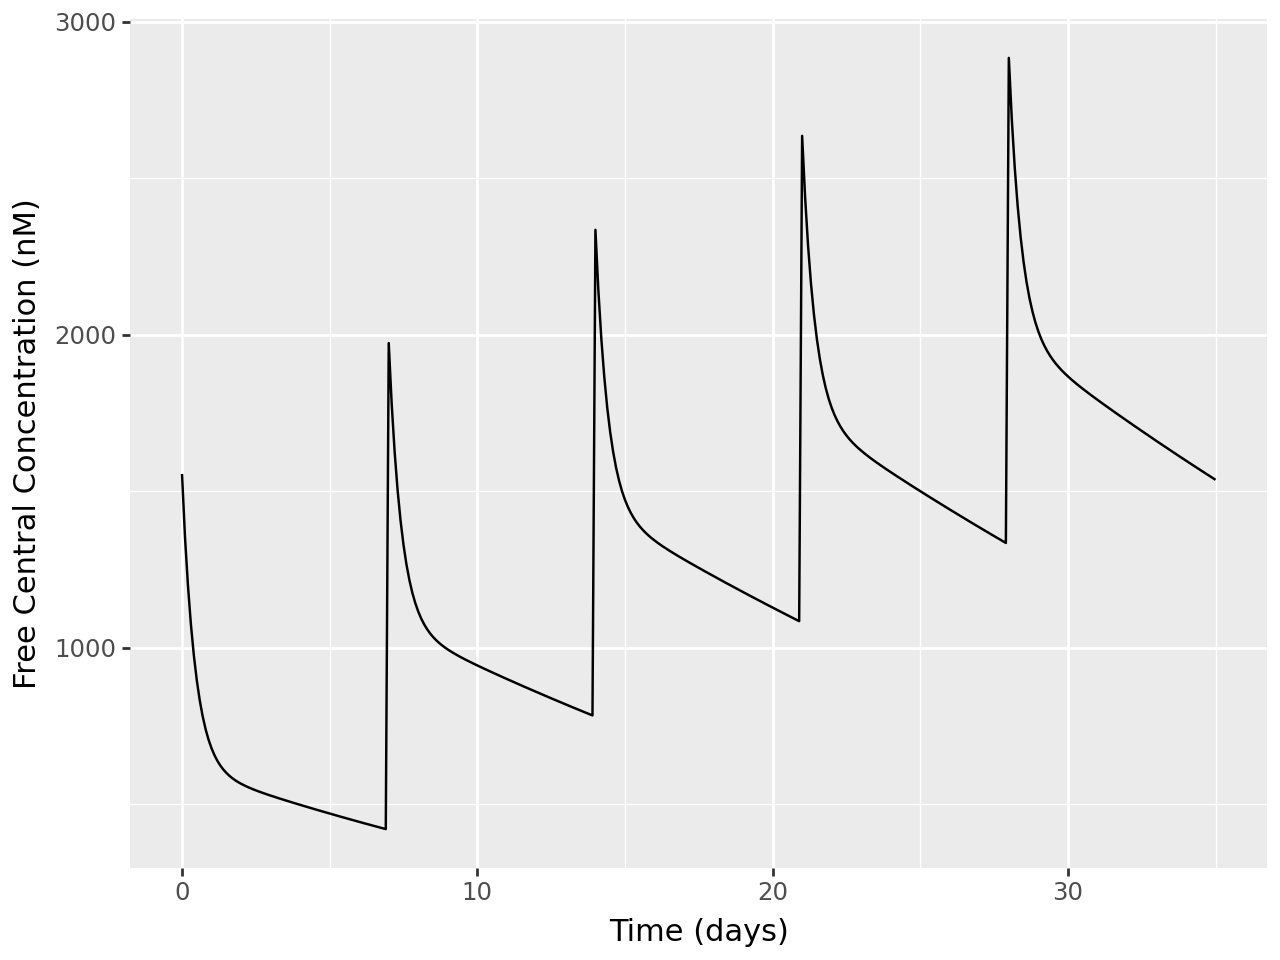

In [8]:
fig = (ggplot()
       + geom_line(data=Tpk_single, mapping=aes(x='t', y='value'))
       + labs(x='Time (days)', y='Free Central Concentration (nM)')
      )
display(fig)

### Log y-axis

PK concentrations often span several orders of magnitude. `scale_y_log10()` switches the y-axis to a log scale. The `breaks` argument controls which tick marks appear. Here, `10.**np.arange(-20, 20)` places a tick at every power of ten. `limits` sets the plot limits.

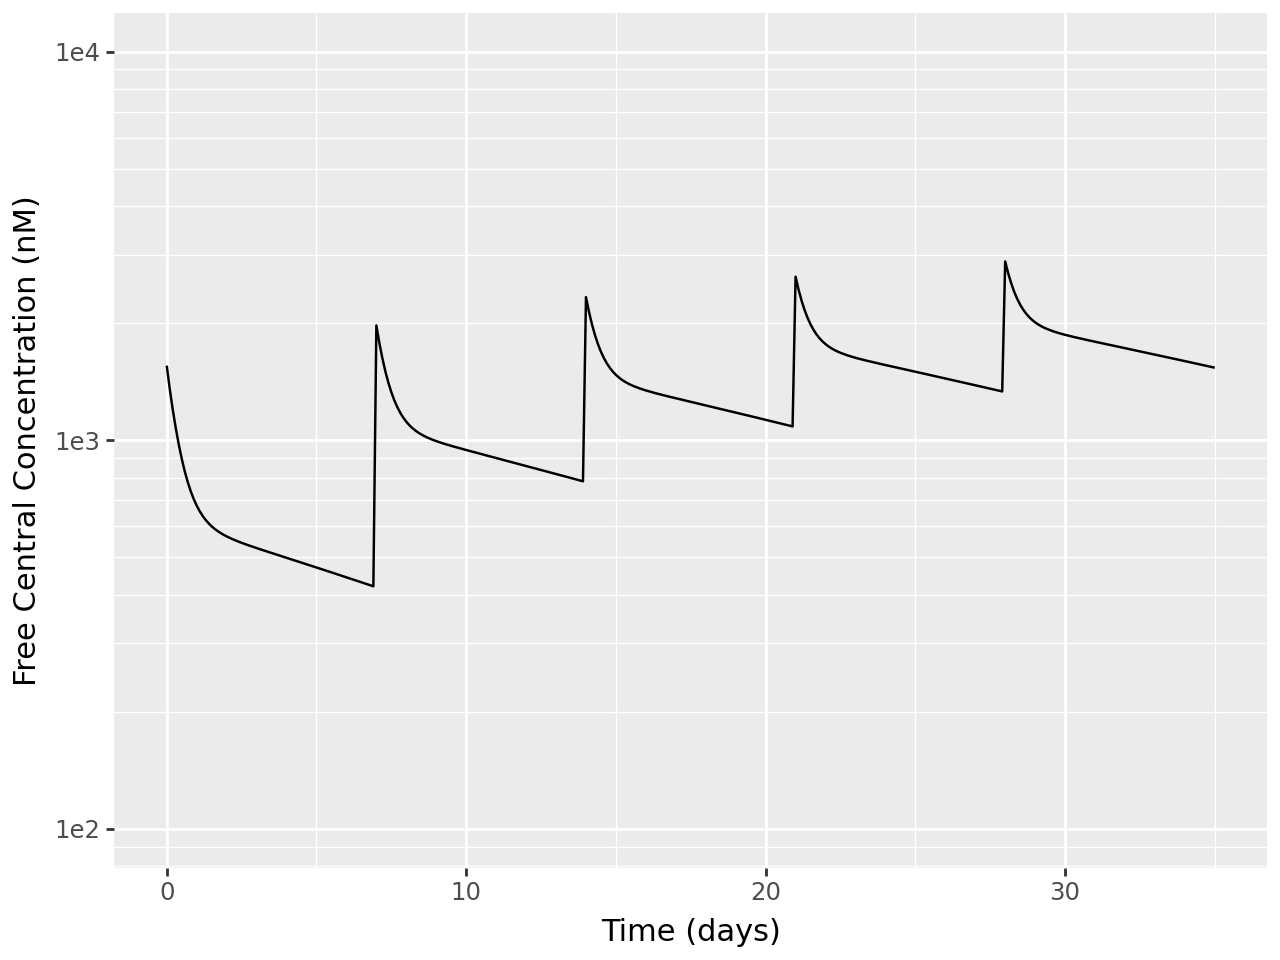

In [9]:
fig_pk_log = (ggplot()
              + geom_line(data=Tpk_single, mapping=aes(x='t', y='value'))
              + labs(x='Time (days)', y='Free Central Concentration (nM)')
              + scale_y_log10(breaks=10.**np.arange(-20, 20), limits=[100, 10_000])
             )
display(fig_pk_log)

### Controlling tick marks on a linear axis

`scale_y_continuous()` provides the same functionality for a linear axis. The example below plots receptor occupancy (0–100 %) with a tick every 10 %:

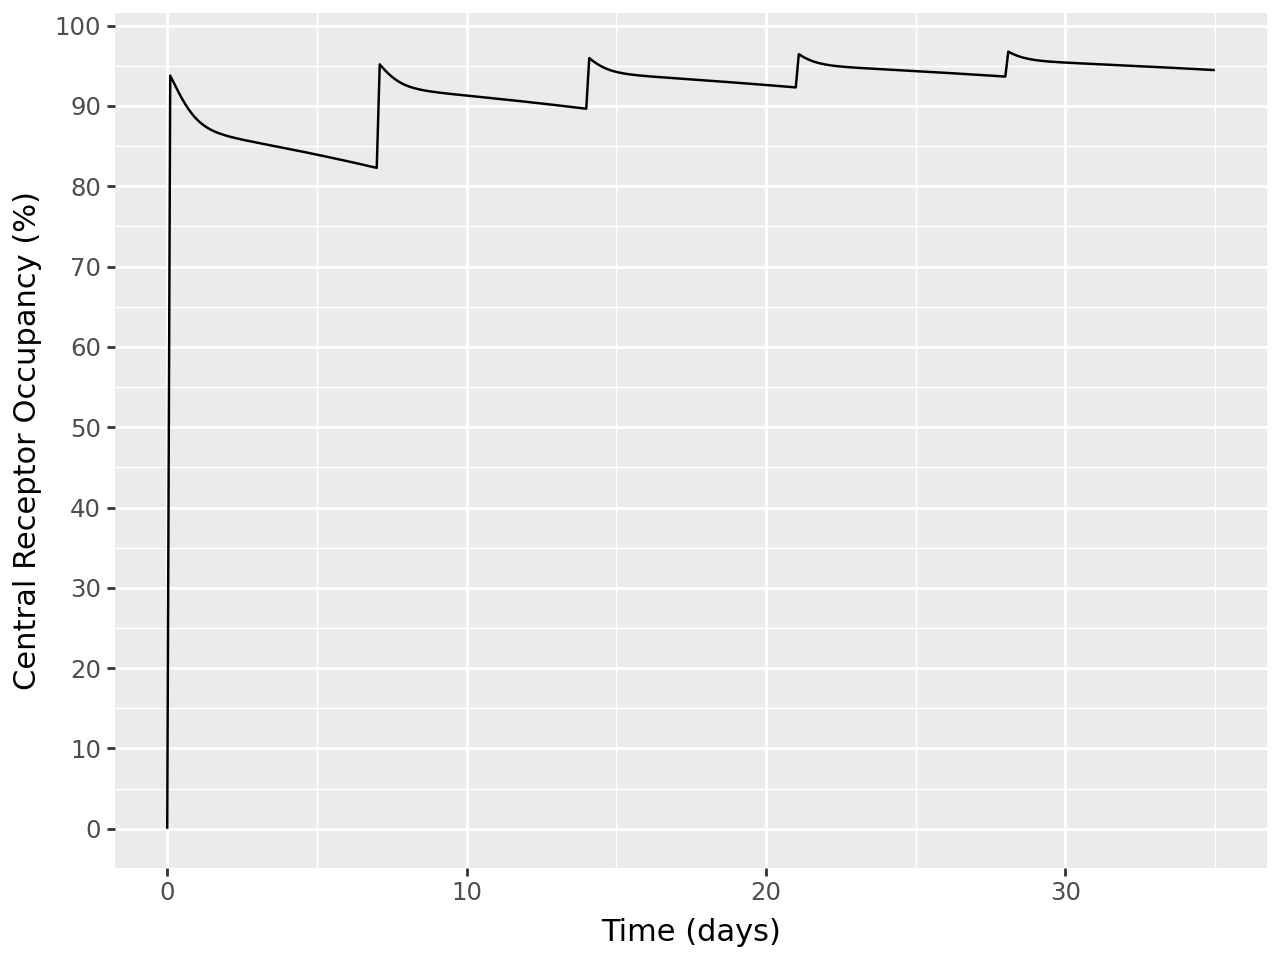

In [10]:
Tro_single = Tsim_results.query('output == "RO_c" and dose_mpk == 10 and route == "Dose_IV"')

fig_ro = (ggplot()
          + geom_line(data=Tro_single, mapping=aes(x='t', y='value'))
          + labs(x='Time (days)', y='Central Receptor Occupancy (%)')
          + scale_y_continuous(breaks=np.linspace(0, 100, 11))
         )
display(fig_ro)

## Section 3 — Mapping Aesthetics to Data Columns

An *aesthetic* is any visual property of a geometry, like x-position, y-position, color, linetype, size, and so on. When you pass a column name inside `aes()`, plotnine maps the values in that column to the aesthetic automatically, one color (or linetype, etc.) per unique value in the column.

### Coloring by dose

Let's plot all four IV dose levels at once, assigning a different color to each. Wrapping the column name in `factor()` inside `aes()` tells plotnine to treat the variable as *categorical* such that each unique value gets its own distinct color and line.

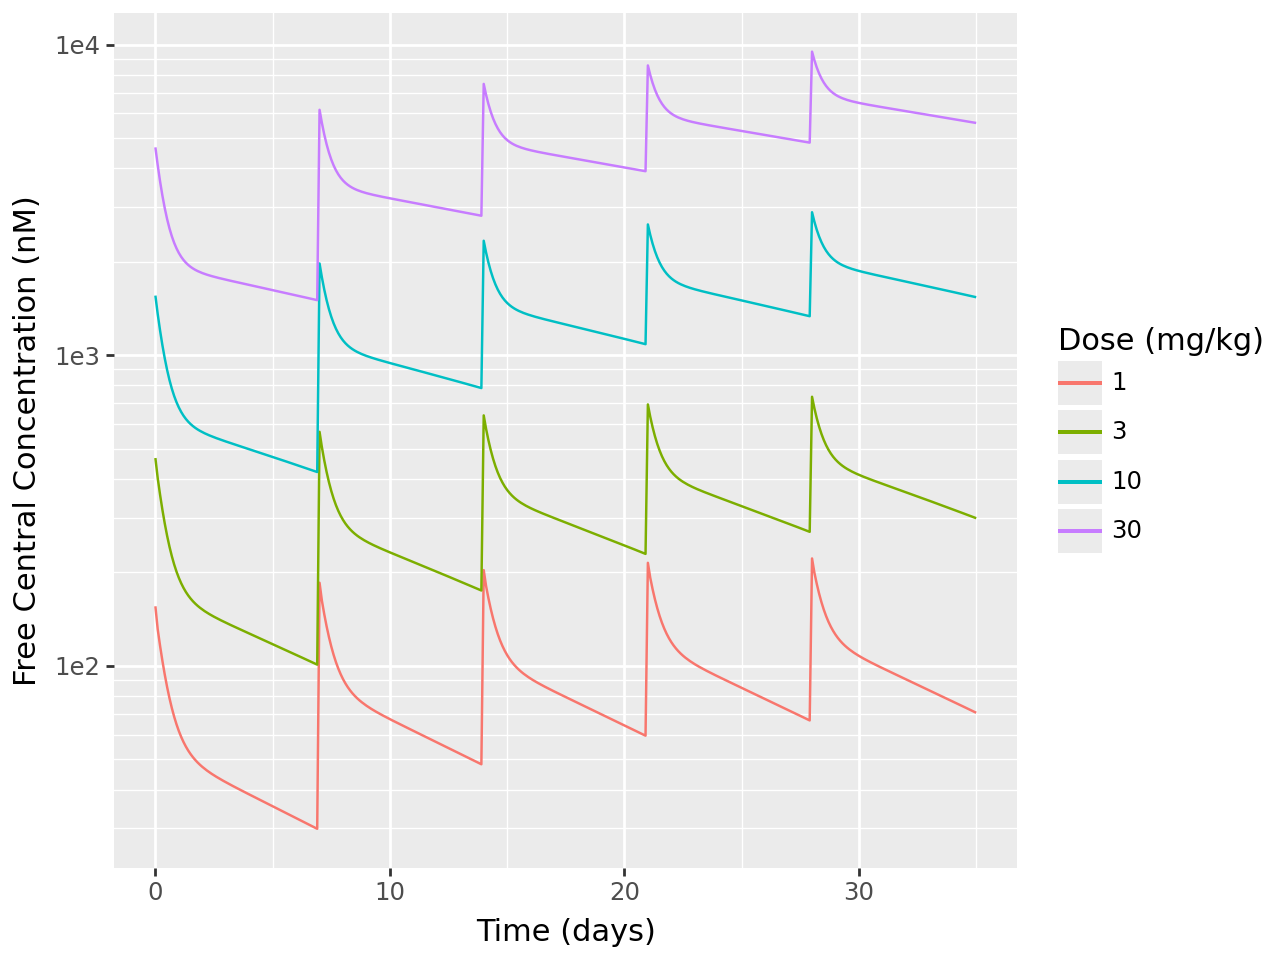

In [11]:
Tpk_IV = Tsim_results.query('output == "free_drug_c" and route == "Dose_IV"')

fig_pk_color = (ggplot()
                + geom_line(data=Tpk_IV, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
                + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
                + scale_y_log10(breaks=10.**np.arange(-20, 20))
               )
display(fig_pk_color)

The `color=` argument inside `labs()` renames the legend title.

### Colors without `factor()`

Without `factor()`, plotnine treats `dose_mpk` as a continuous variable because it is a numeric column and assigns colors on a smooth spectrum from low to high, grouping all the points into a single line.

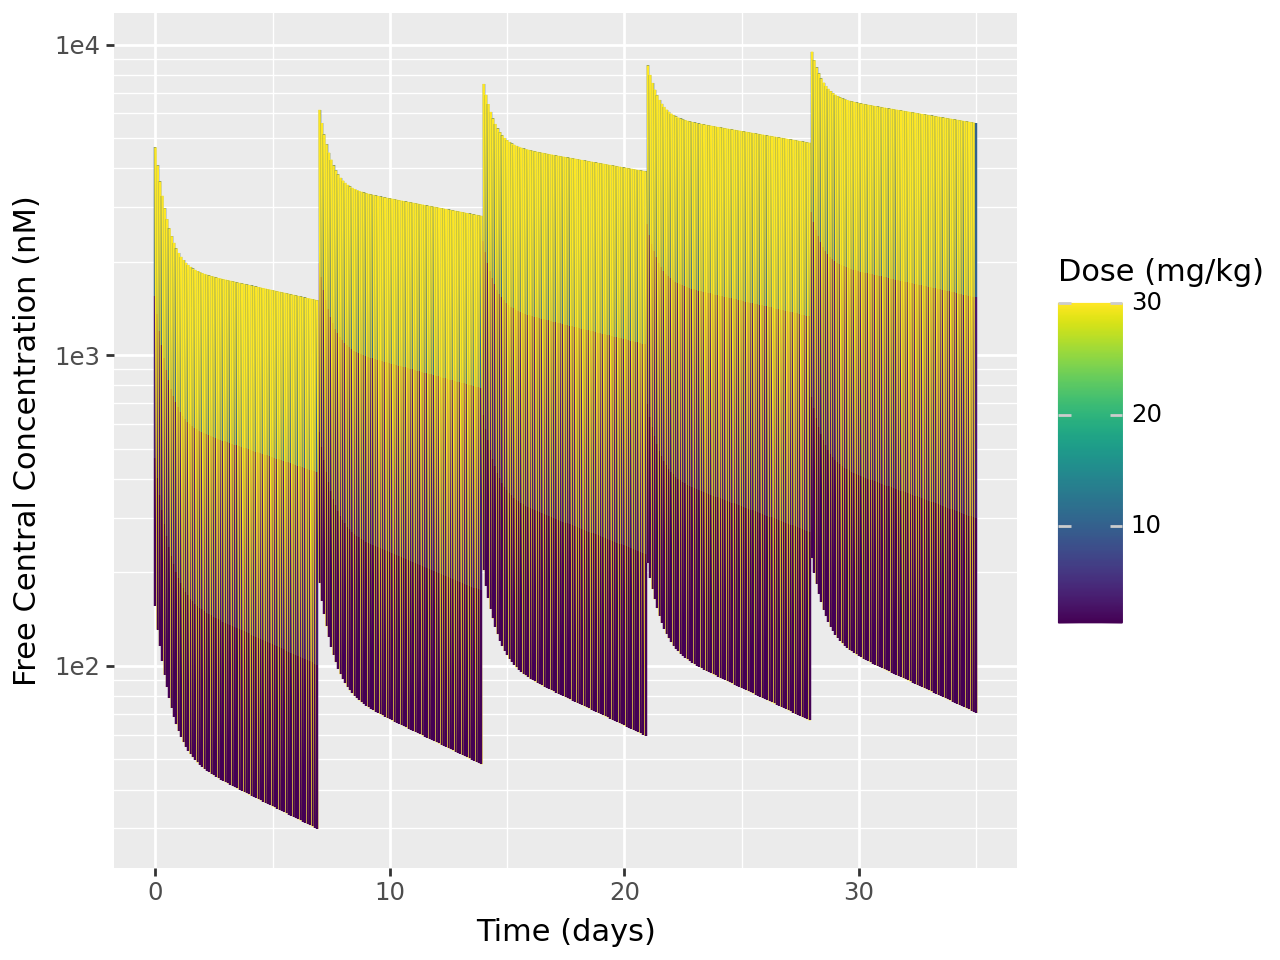

In [12]:
fig = (ggplot()
       + geom_line(data=Tpk_IV, mapping=aes(x='t', y='value', color='dose_mpk'))
       + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
       + scale_y_log10(breaks=10.**np.arange(-20, 20))
      )
display(fig)

### Using multiple aesthetics at once

You can map several columns simultaneously. The example below uses `color` for dose level and `linetype` for dosing route.

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


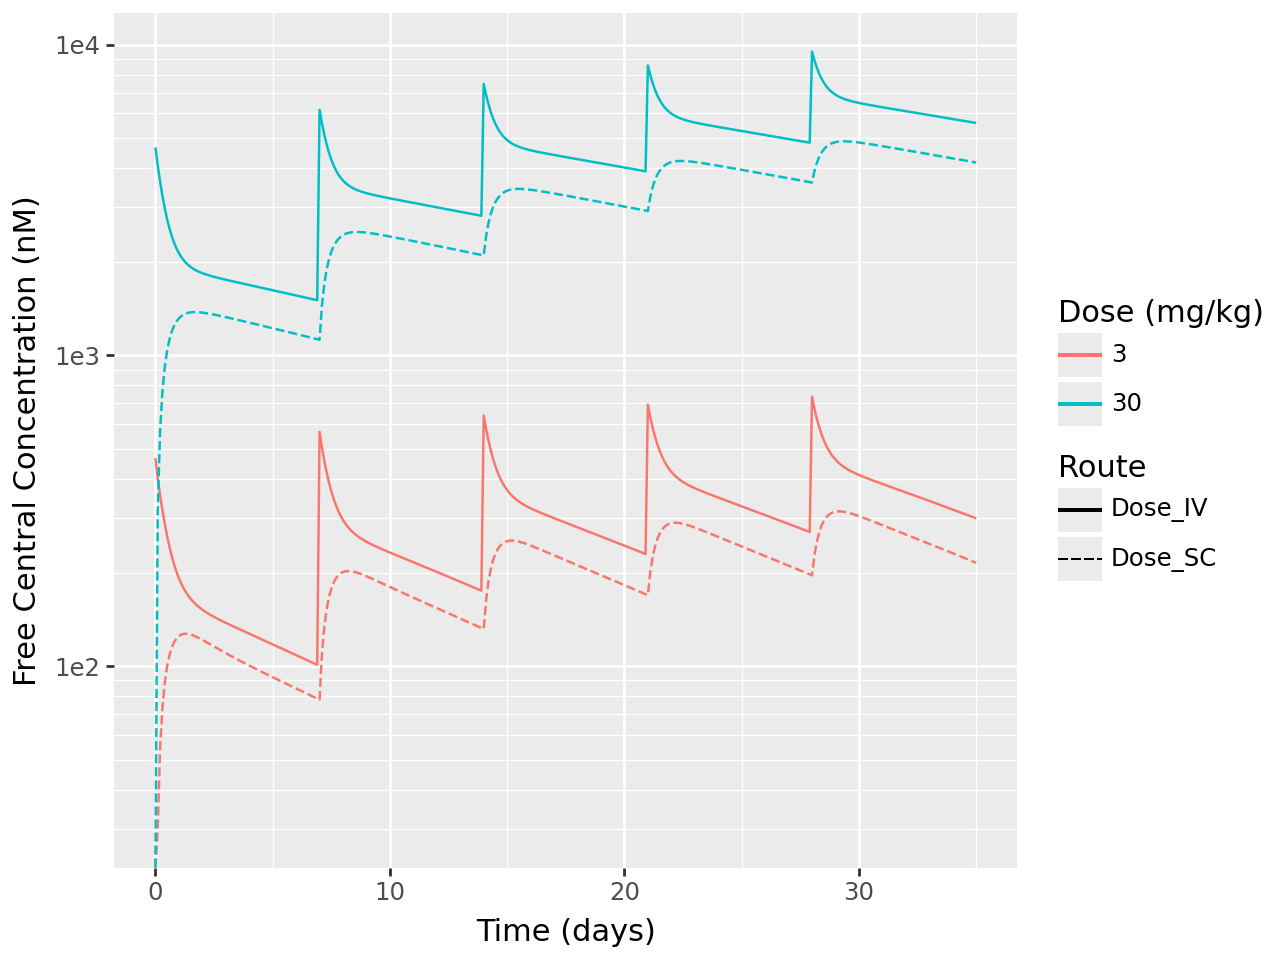

In [13]:
# Filter to two dose levels so the plot stays readable
Tpk_two = Tsim_results.query('output == "free_drug_c" and dose_mpk in [3, 30]')

fig_multi = (ggplot()
             + geom_line(data=Tpk_two,
                         mapping=aes(x='t', y='value',
                                     color='factor(dose_mpk)', linetype='route'))
             + labs(x='Time (days)', y='Free Central Concentration (nM)',
                    color='Dose (mg/kg)', linetype='Route')
             + scale_y_log10(breaks=10.**np.arange(-20, 20))
            )
display(fig_multi)

Other commonly used aesthetics in IQ plots:

| Aesthetic | Column type | Effect |
|-----------|-------------|--------|
| `color` | Categorical or numeric | Line/point color |
| `linetype` | Categorical | Solid, dashed, dotted, ... |
| `size` | Numeric | Line width or point diameter |
| `alpha` | Numeric | Transparency (range mapped to 0–1) |
| `shape` | Categorical | Point shape (for `geom_point`) |

## Section 4 — Faceting: Small Multiples

Faceting splits a single plot into a grid of panels, one per level of a grouping variable (or combination of variables). This is one of the most powerful features of the grammar of graphics — it lets you compare many conditions at a glance without layering everything onto one crowded chart.

### `facet_wrap()` — one grouping variable

`facet_wrap('column')` creates one panel per unique value in `column` and arranges them automatically:

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


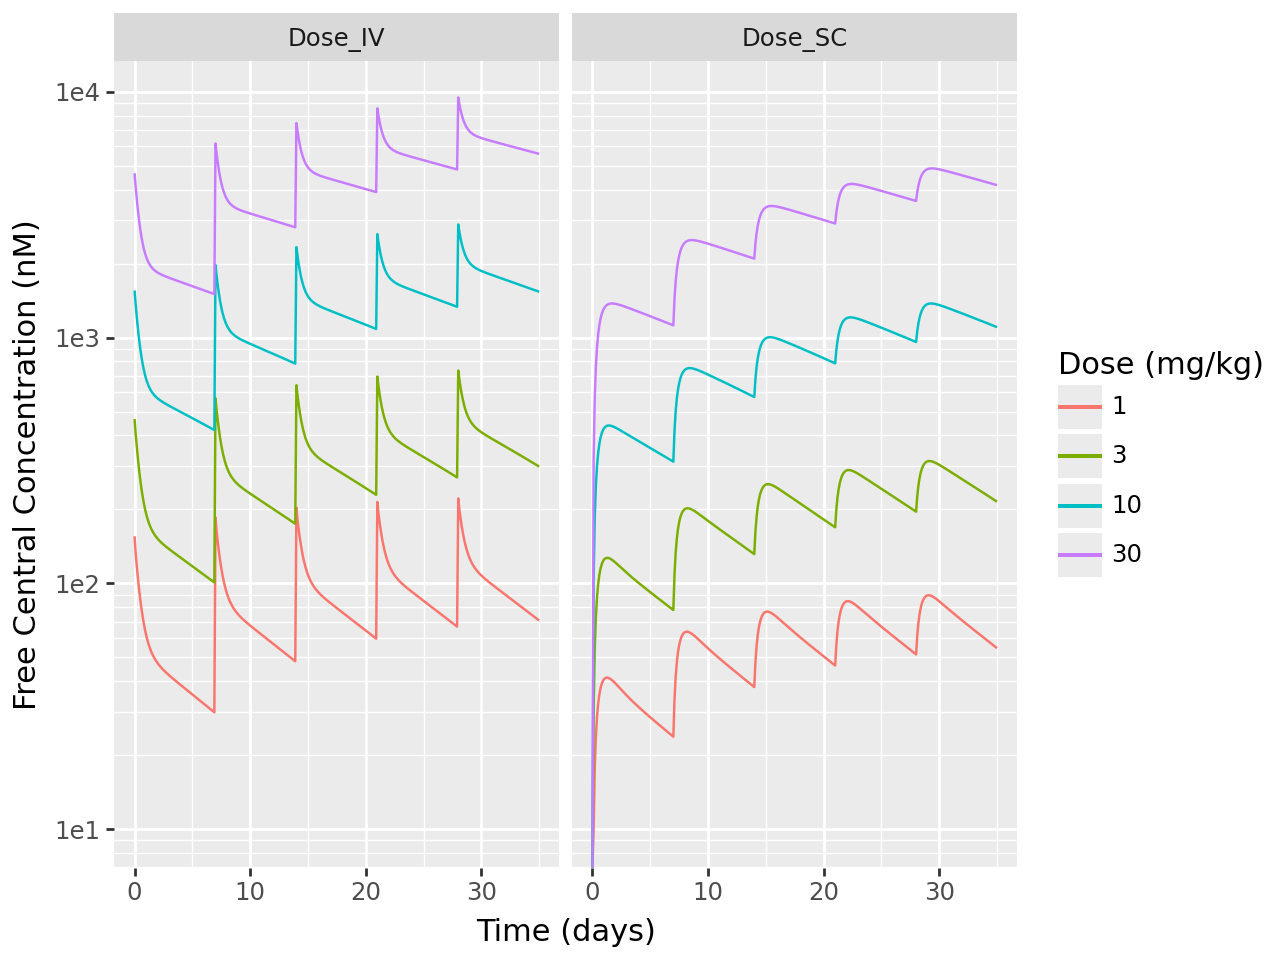

In [14]:
Tpk_all = Tsim_results.query('output == "free_drug_c"')

fig_wrap = (ggplot()
            + geom_line(data=Tpk_all, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
            + facet_wrap('route')
            + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
            + scale_y_log10(breaks=10.**np.arange(-20, 20))
           )
display(fig_wrap)

### Custom panel labels with `labeller`

By default, panels are labeled with the raw column value (`'Dose_IV'`, `'Dose_SC'`). A `labeller` function lets you reformat the label. The lambda below strips the `'Dose_'` prefix, leaving just `'IV'` or `'SC'`:

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


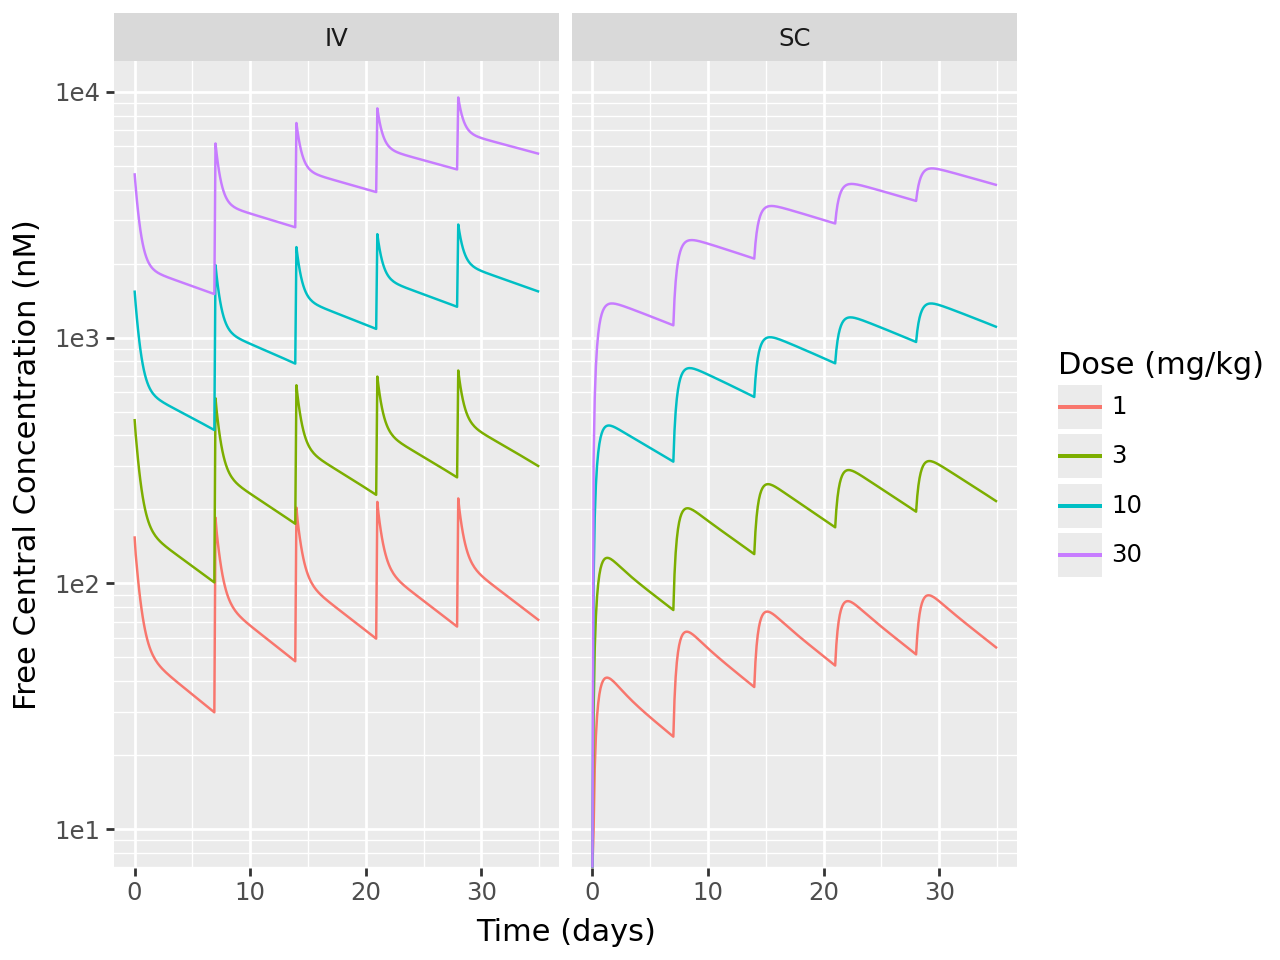

In [15]:
fig_wrap_labels = (ggplot()
                   + geom_line(data=Tpk_all, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
                   + facet_wrap('route', labeller=lambda x: x.split('_')[1])
                   + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
                   + scale_y_log10(breaks=10.**np.arange(-20, 20))
                  )
display(fig_wrap_labels)

### Controlling layout: `ncol`, `figure_size`, and `scales`

- **`ncol=`** controls how many columns `facet_wrap` uses when it lays out the panels.
- **`figure_size=(width, height)`** inside `theme()` sets the total figure dimensions in inches.
- **`scales='free_y'`** (or `'free_x'`, `'free'`) allows axes to vary independently across panels. The default is `'fixed'` (shared axes).

Here `ncol=1` stacks all panels vertically, which works well when you want to compare shapes across panels that share the same x-axis:

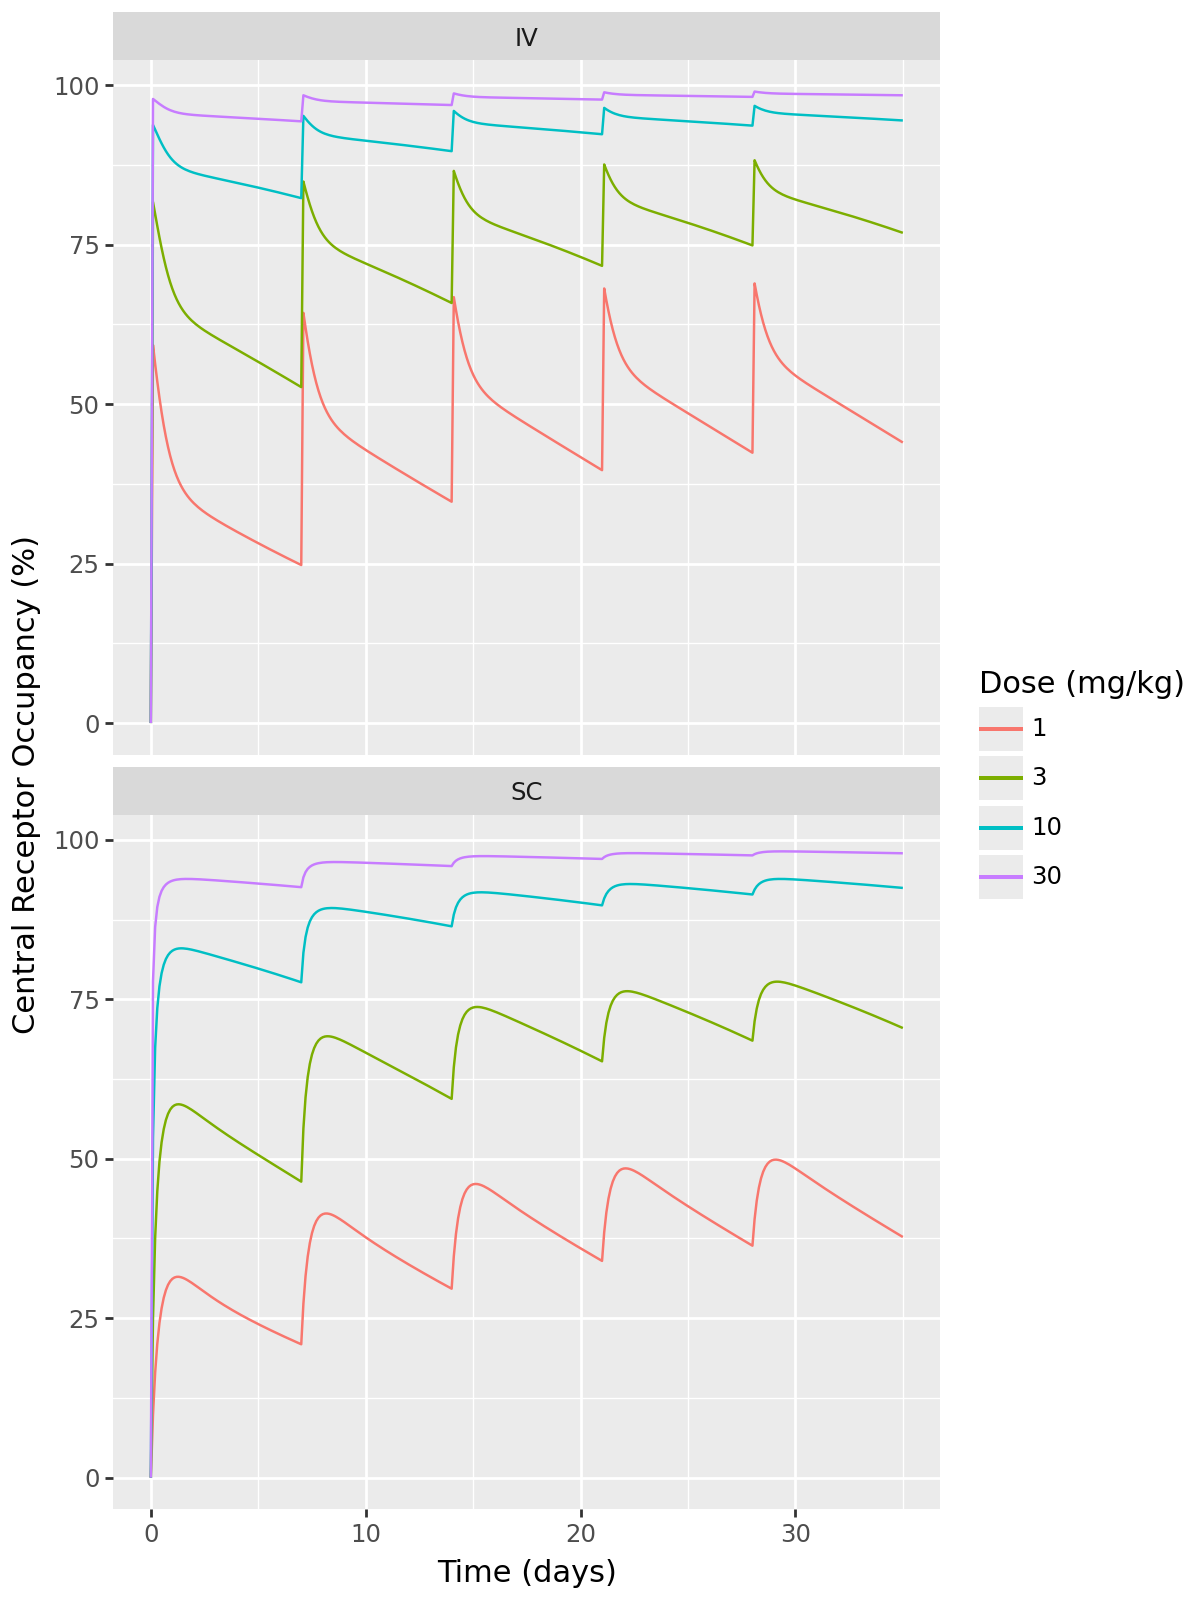

In [16]:
Tro_all = Tsim_results.query('output == "RO_c"')

fig_layout = (ggplot()
              + geom_line(data=Tro_all, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
              + facet_wrap('route', ncol=1, labeller=lambda x: x.split('_')[1])
              + labs(x='Time (days)', y='Central Receptor Occupancy (%)', color='Dose (mg/kg)')
              + theme(figure_size=(6, 8))
             )
display(fig_layout)

### `facet_grid()` — two grouping variables

`facet_grid('row_var ~ col_var')` creates a rectangular grid of panels, one row level × one column level. This is useful for comparing two categorical dimensions simultaneously.

The example below shows both outputs (rows) across both routes (columns). Because the two outputs are on very different scales, `scales='free_y'` allows each row to have its own y-axis range.

Both raw column values (`'free_drug_c'`, `'Dose_IV'`, ...) make poor panel titles, so readable label columns are created first with dictionary mappings and used directly in the `facet_grid` formula:

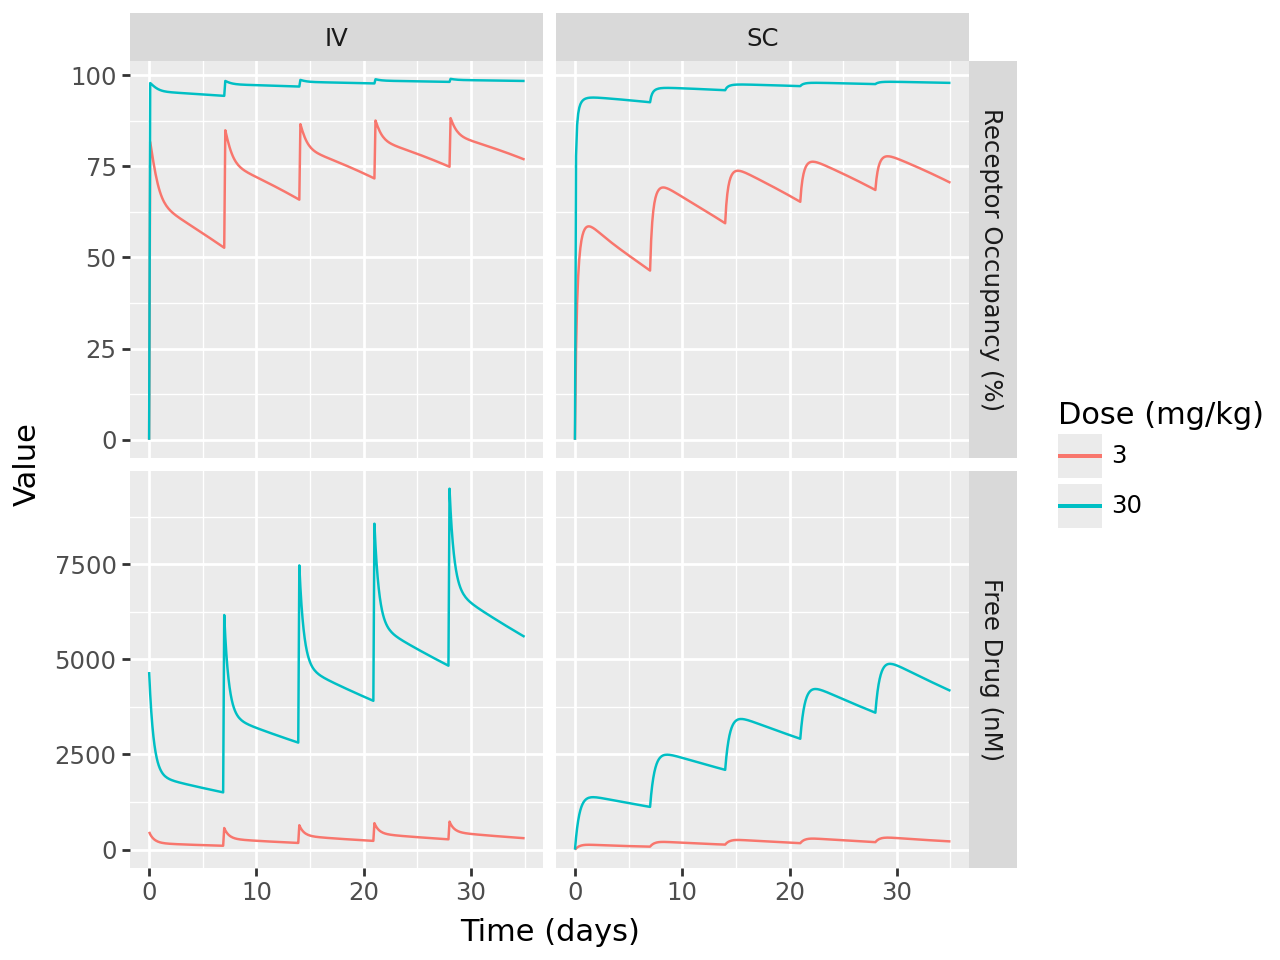

In [17]:
Tgrid = Tsim_results.query('dose_mpk in [3, 30]').copy()

labels = {'free_drug_c': 'Free Drug (nM)', 
          'RO_c': 'Receptor Occupancy (%)',
          'Dose_IV': 'IV', 
          'Dose_SC': 'SC'}

fig_grid = (ggplot()
            + geom_line(data=Tgrid, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
            + facet_grid('output ~ route', scales='free_y', labeller=labels)
            + labs(x='Time (days)', y='Value', color='Dose (mg/kg)')
           )
display(fig_grid)

## Section 5 — Themes and Visual Polish

A *theme* controls the non-data elements of a plot like background, gridlines, font sizes, legend placement, and so on. Plotnine ships with several ready-made themes.

### Built-in themes

`theme_bw()` replaces the grey default background with a white panel and black border:

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


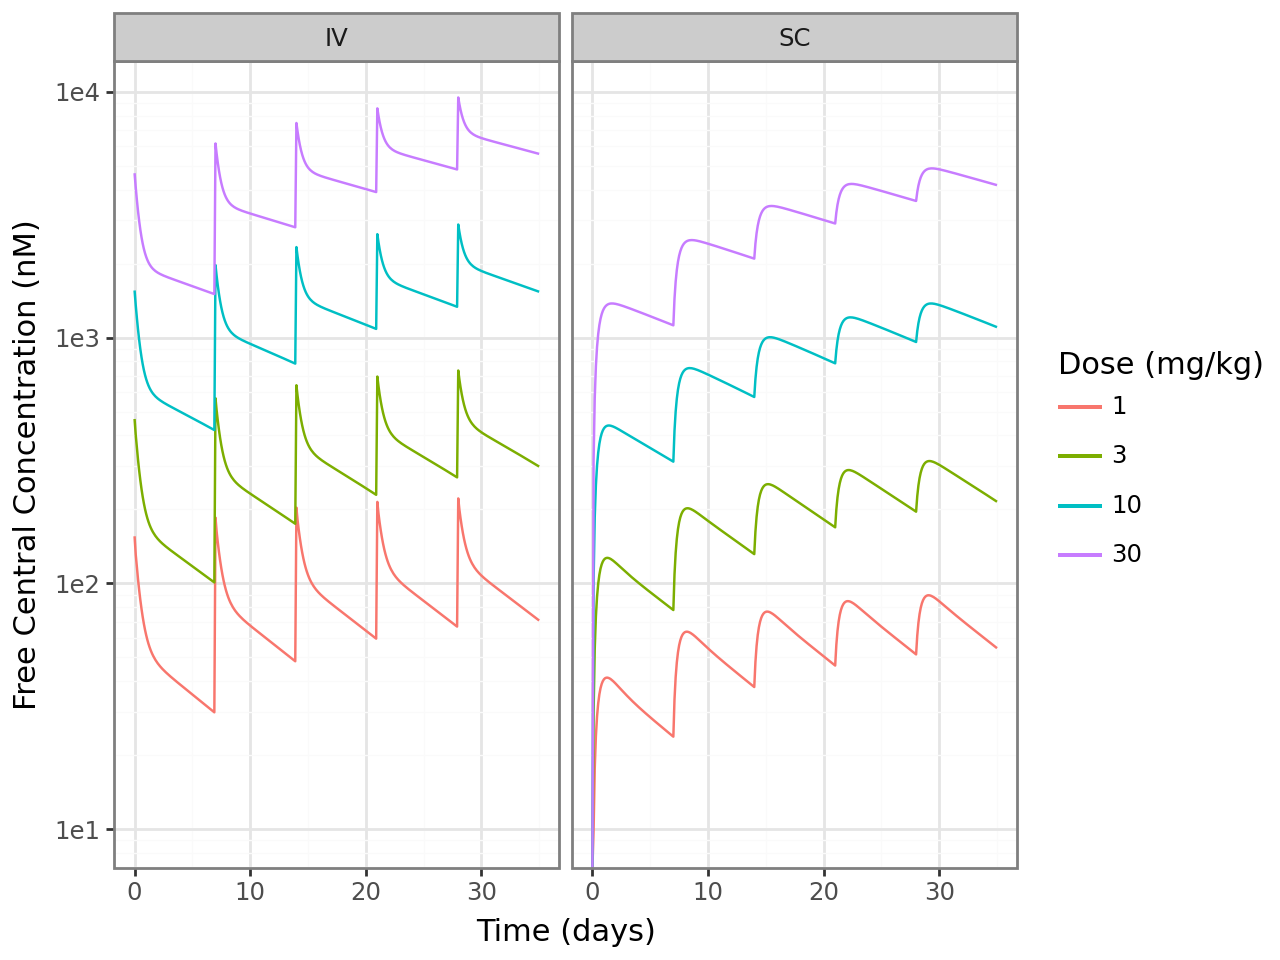

In [18]:
fig_bw = (ggplot()
          + geom_line(data=Tpk_all, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
          + facet_wrap('route', labeller=lambda x: x.split('_')[1])
          + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
          + scale_y_log10(breaks=10.**np.arange(-20, 20))
          + theme_bw()
         )
display(fig_bw)

`theme_minimal()` removes the outer box, keeping only light gridlines.

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


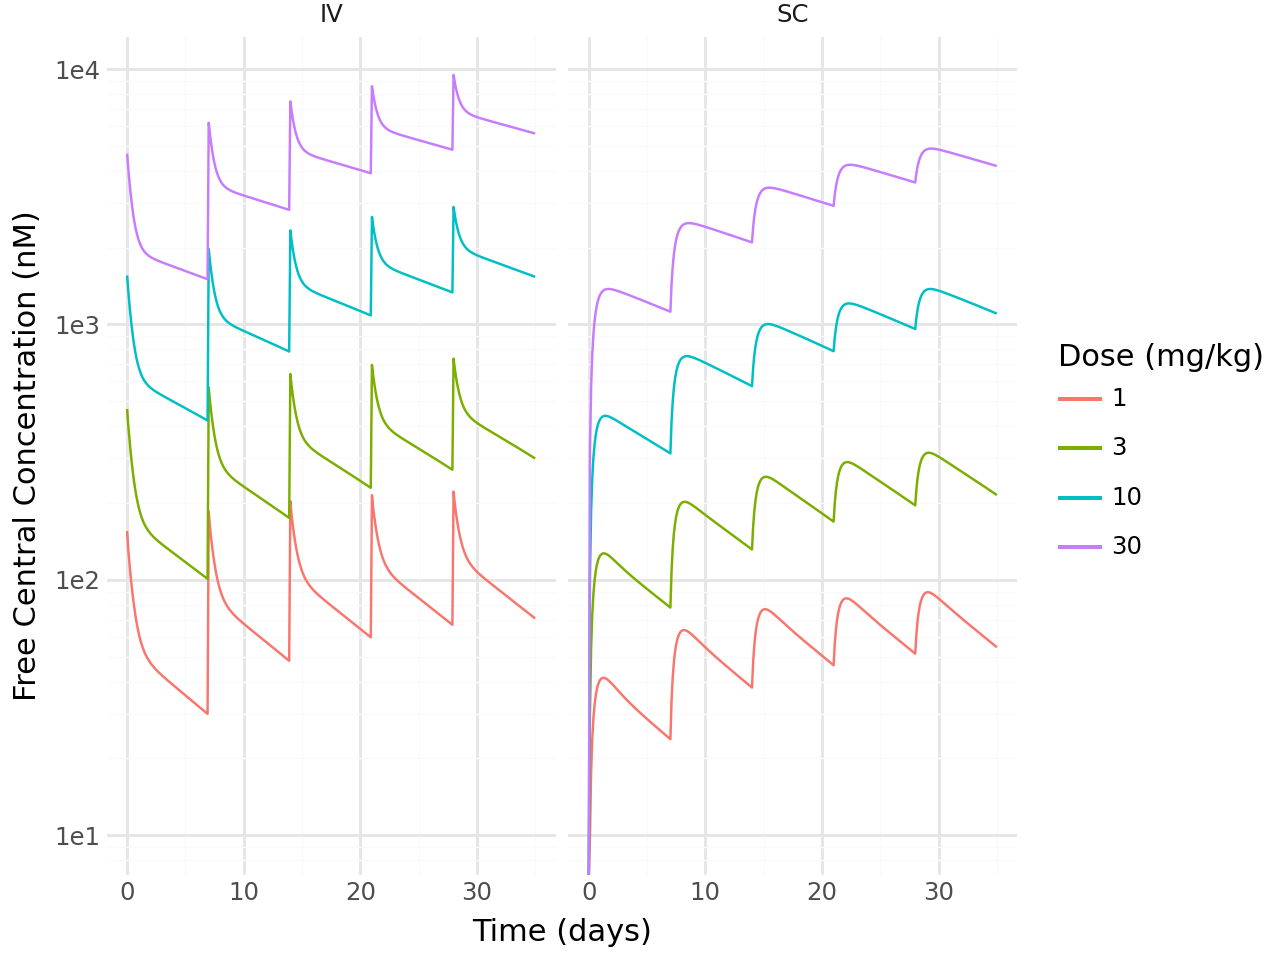

In [19]:
fig_minimal = (ggplot()
               + geom_line(data=Tpk_all, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
               + facet_wrap('route', labeller=lambda x: x.split('_')[1])
               + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
               + scale_y_log10(breaks=10.**np.arange(-20, 20))
               + theme_minimal()
              )
display(fig_minimal)

### One-off overrides with `theme()`

Adding `theme()` after a built-in theme lets you override specific elements. Commonly adjusted options:

- `figure_size=(width, height)` — dimensions in inches
- `dpi=` — resolution for display and saving
- `aspect_ratio=` — height-to-width ratio of each panel
- `legend_position='bottom'` (or `'top'`, `'left'`, `'none'`) — legend placement

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


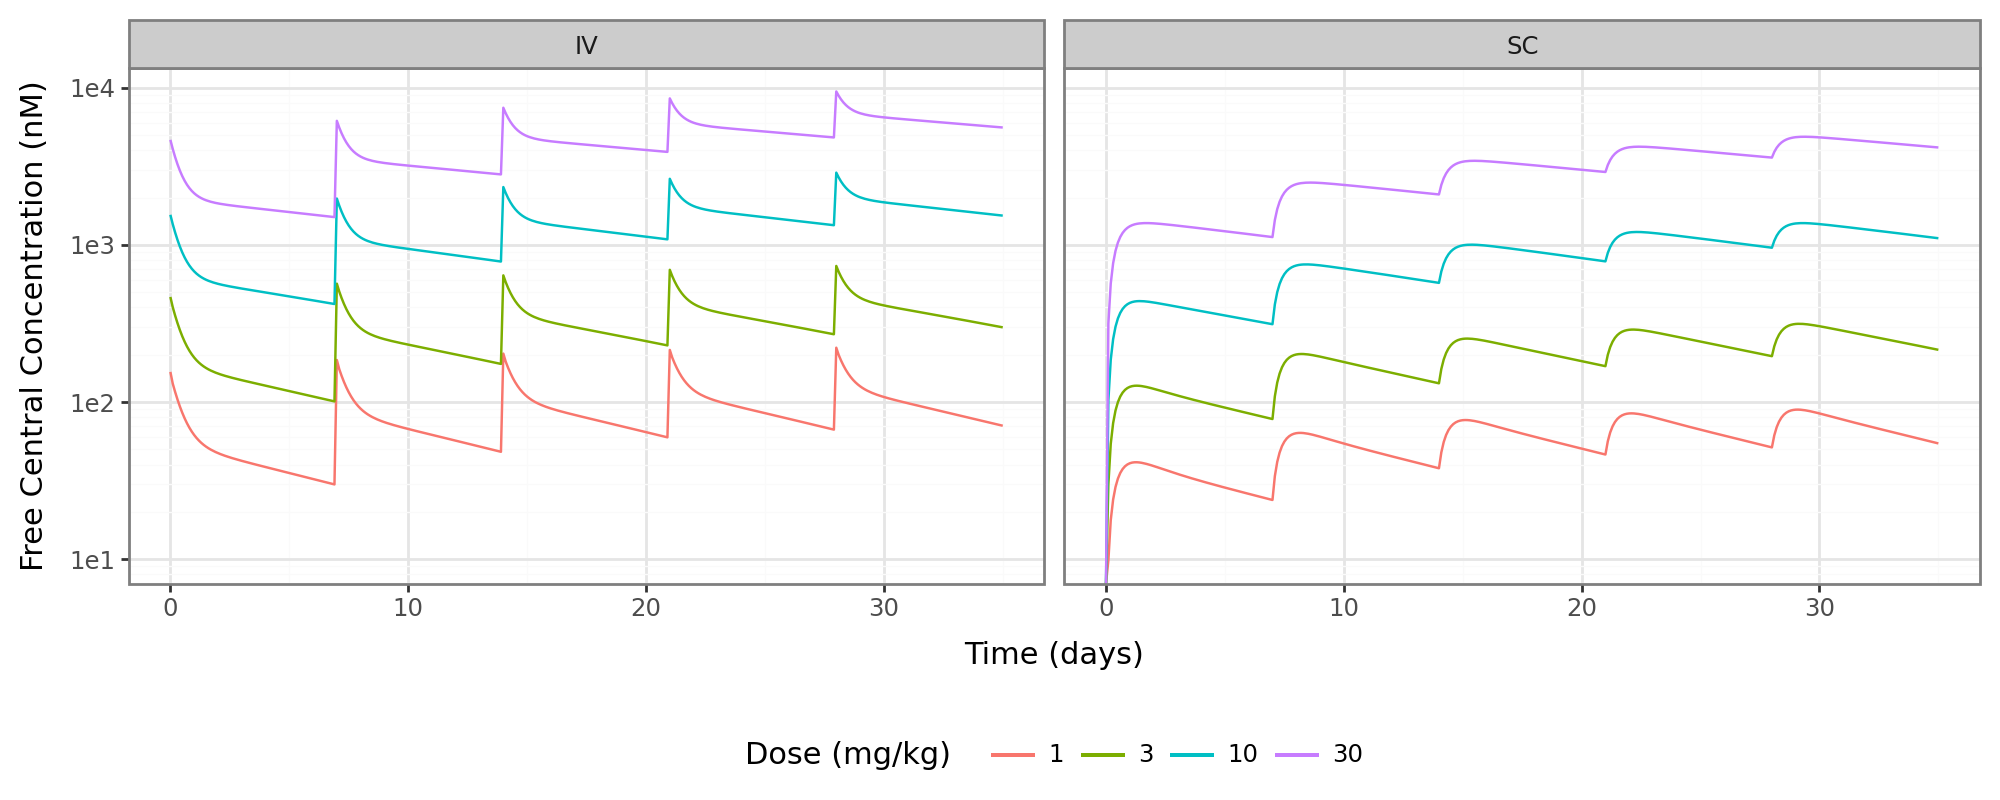

In [20]:
fig_custom_theme = (ggplot()
                    + geom_line(data=Tpk_all, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
                    + facet_wrap('route', labeller=lambda x: x.split('_')[1])
                    + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
                    + scale_y_log10(breaks=10.**np.arange(-20, 20))
                    + theme_bw()
                    + theme(figure_size=(10, 4), legend_position='bottom')
                   )
display(fig_custom_theme)

### Color palettes

**`scale_color_brewer()`** applies a [ColorBrewer](https://colorbrewer2.org) palette. The ColorBrewer website lets you filter palettes by properties such as colorblind-friendliness and print-friendliness. Not all palettes have these properties, so it is worth checking before choosing one for a report or publication:

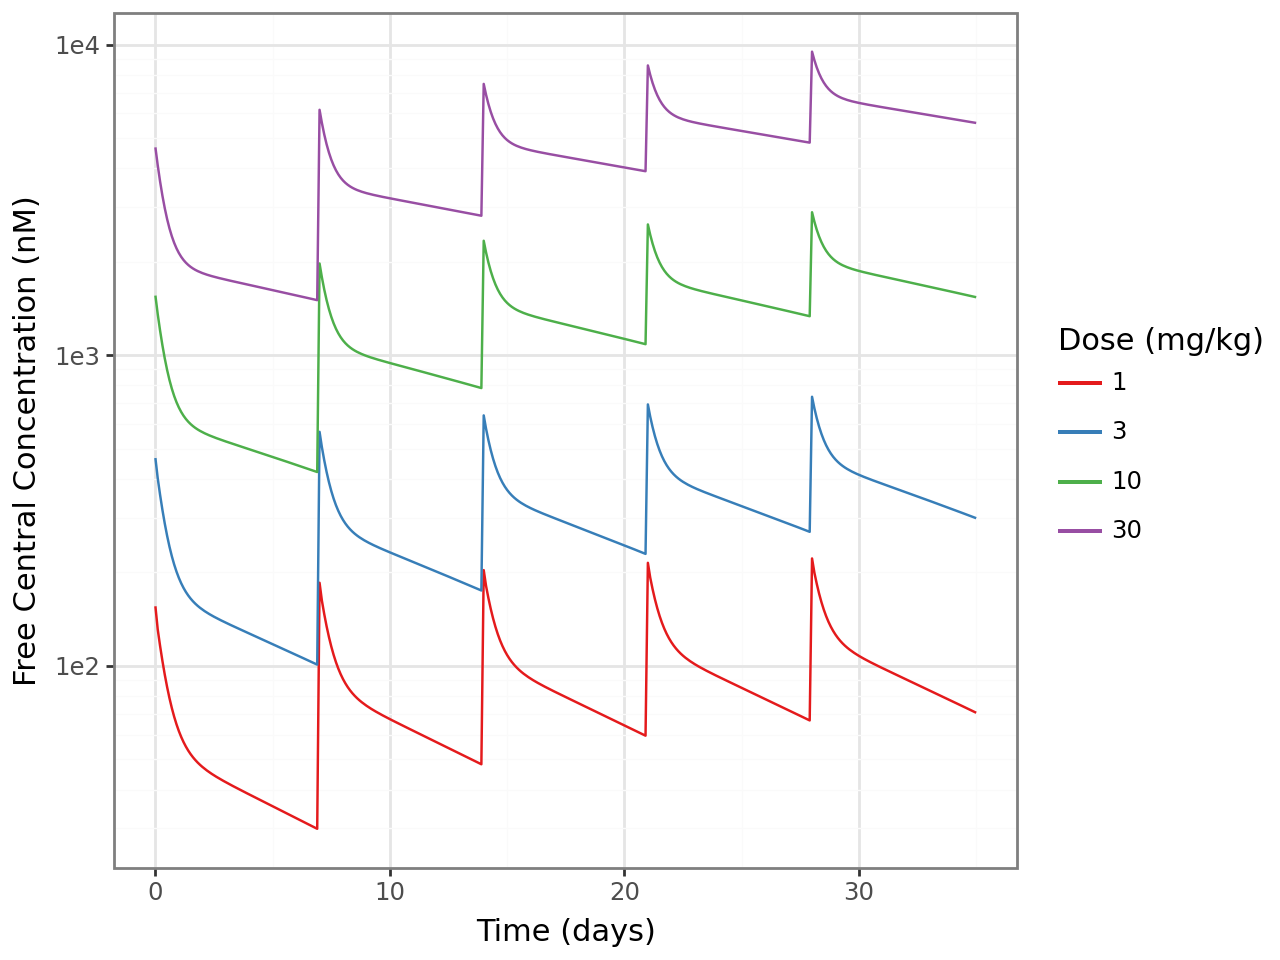

In [21]:
fig_brewer = (ggplot()
              + geom_line(data=Tpk_IV, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
              + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
              + scale_y_log10(breaks=10.**np.arange(-20, 20))
              + scale_color_brewer(type='qual', palette='Set1')
              + theme_bw()
             )
display(fig_brewer)

**`scale_color_manual()`** lets you specify exact hex colors. This is useful when you need to match company or journal color standards:

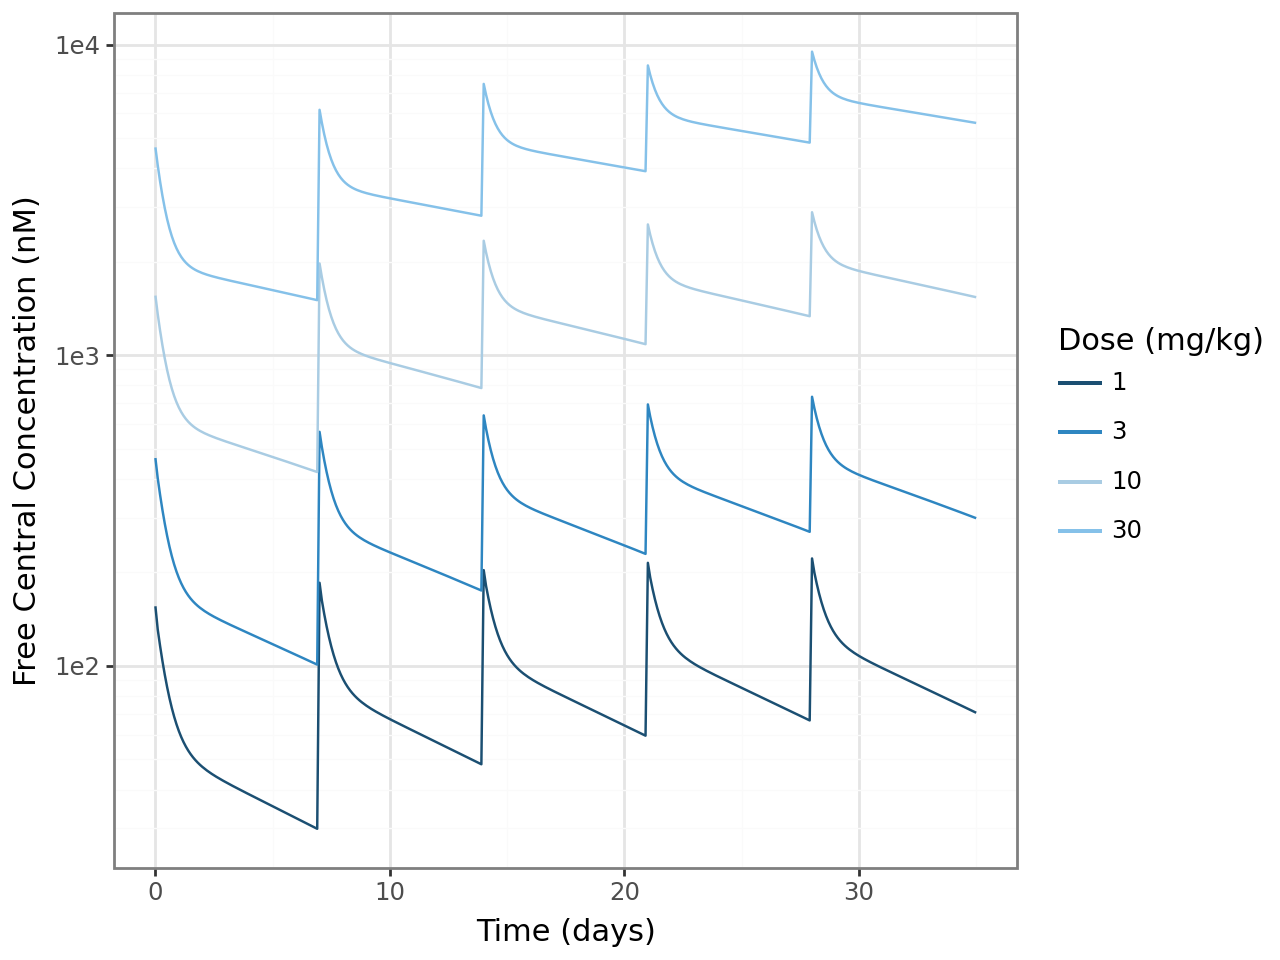

In [22]:
custom_colors = ['#1B4F72', '#2E86C1', '#A9CCE3', '#85C1E9']

fig_manual = (ggplot()
              + geom_line(data=Tpk_IV, mapping=aes(x='t', y='value', color='factor(dose_mpk)'))
              + labs(x='Time (days)', y='Free Central Concentration (nM)', color='Dose (mg/kg)')
              + scale_y_log10(breaks=10.**np.arange(-20, 20))
              + scale_color_manual(values=custom_colors)
              + theme_bw()
             )
display(fig_manual)

### Saving figures

Call `.save()` on a figure object to write it to disk. The file format is inferred from the extension. Common keyword arguments:

- `dpi=` — resolution in dots per inch (300 is standard for publications)
- `width=`, `height=` — override the figure dimensions (in inches by default)
- `units=` — units for width/height (`'in'`, `'cm'`, `'mm'`)

In [23]:
fig_manual.save('pk_plot.png', dpi=300)

/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 6.4 x 4.8 in image.
/home/jovyan/environment/.pixi/envs/default/lib/python3.14/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: pk_plot.png


## Section 6 — Quick Reference

### Geometry functions

| Geometry | Typical use | Key aesthetics |
|----------|-------------|----------------|
| `geom_line()` | Simulation time-courses | `x`, `y`, `color`, `linetype`, `size` |
| `geom_point()` | Observed data | `x`, `y`, `color`, `shape`, `size` |
| `geom_segment()` | Tornado plot bars | `x`, `xend`, `y`, `yend`, `color`, `size` |
| `geom_vline()` | Vertical reference line | `xintercept` |
| `geom_hline()` | Horizontal reference line | `yintercept` |

### Scales

| Scale | Purpose |
|-------|---------|
| `scale_y_log10(breaks=...)` | Log₁₀ y-axis with custom tick marks |
| `scale_y_continuous(breaks=...)` | Linear y-axis with custom tick marks |
| `scale_color_brewer(type=, palette=)` | ColorBrewer palette |
| `scale_color_manual(values=[...])` | Arbitrary hex colors |
| `scale_y_discrete(limits=[...])` | Reorder a categorical y-axis |

### Faceting

| Function | Use |
|----------|-----|
| `facet_wrap('col')` | One variable, auto-arranged grid |
| `facet_wrap('col', ncol=N)` | Force N columns |
| `facet_grid('row ~ col')` | Two variables, explicit rows × columns |
| `facet_grid(..., scales='free_y')` | Independent y-axis per row |

### Theme and layout

| Function | Effect |
|----------|--------|
| `theme_bw()` | White background, black border |
| `theme_minimal()` | Minimal style, no outer box |
| `theme_classic()` | Clean axes, no gridlines |
| `theme(figure_size=(w, h))` | Set dimensions in inches |
| `theme(legend_position='bottom')` | Move legend |
| `labs(x=, y=, color=, title=)` | Set all labels |
| `fig.save('out.png', dpi=300)` | Save to file |